<a href="https://colab.research.google.com/github/DS-Ninja/Dmitrij-Levyj/blob/Main/%233%20Project%20-%20Predictive_Analysis_of_the_Best_Ship_Size_for_Chemical_Tankers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

---

[![WhatsApp](https://img.shields.io/badge/Whatsapp-Blue?style=social&logo=Whatsapp)](https://call.whatsapp.com/voice/WAl0Hu47THhpnB7d2mimjf)
[![Messenger](https://img.shields.io/badge/Messenger-Blue?style=social&logo=Messenger)](https://m.me/dimitrioespanol)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Blue?style=social&logo=LinkedIn)](https://www.linkedin.com/in/dmitrij-levyj)
[![Facebook](https://img.shields.io/badge/Facebook-Blue?style=social&logo=facebook)](https://www.facebook.com/dimitrioespanol)

[![Instagram](https://img.shields.io/badge/Instagram-Blue?style=social&logo=instagram)](https://www.instagram.com/2t_ninja/)
[![GitHub](https://img.shields.io/badge/GitHub-Blue?style=social&logo=github)](https://github.com/DS-Ninja/Dmitrij-Levyj)
[![Kaggle](https://img.shields.io/badge/Kaggle-Blue?style=social&logo=kaggle)](https://www.kaggle.com/dmitrijlevyj)
[![Tableau](https://img.shields.io/badge/Tableau-Blue?style=social&logo=Tableau)](https://public.tableau.com/app/profile/dmitrij.levyj)
</center>

---


<center>


Predictive Analysis of the Best Ship Size for Chemical Tankers

</center>

---

##### Author

👨‍💻 **Dmitrij Levyj**
- **Expertise**: Data Science and Maritime Industry
- **Tagline**: **"Details Matter"**





***
***

##**Contents**


* **1. Introduction**
* **2. Daily Costs + Calculate Profitability**
    * 2.1 Analyze Operating Costs
    * 2.2 Visualize Cost Breakdown
    * 2.3 Calculate Profitability
    * 2.4 Insights
   
* **3. Efficiency Analysis (Cost per Ton-Mile)**
    * 3.1 Cost per Ton-Mile
    
* **4. Scenario Analysis**
    * 4.1 Low and high fuel price scenarios
    * 4.2 low and high demand charter rate impact
* **5. Composite Ranking of Vessel Sizes**
    * 5.1 Composite Score - best vessel size under different criteria (With out port restrictions)
* **6. Draft restriction (8 mtrs / 12 / mtrs / 15 mtrs)**
    * 6.1 Compatible ports for each vessel size
* **7. Scenarios to Test**
    * 7.1 Scenario 1: Prioritize Small Ports
    * 7.2 Scenario 2: Scenario 2: Prioritize Profitability
    * 7.3 Scenario 3: Balanced Weights
    * 7.4 Balanced all scenarios into a DataFrame
    * 7.5 Graph - Balanced all scenarios into a DataFrame
* **8. Final Conclusions and Recommendations**   

***
***


## Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1.Introduction

**Purpose**

The goal of this analysis is to determine the most efficient and profitable size for chemical tankers based on key operational and financial metrics.

**Objectives**
- Analyze the daily operating costs of different vessel sizes.
- Evaluate profitability and cost efficiency through various metrics (e.g., cost per ton-mile).
- Conduct scenario analysis to understand the impact of fuel price changes and charter rate fluctuations.
- Provide actionable recommendations based on findings.

This notebook contains data processing steps, cost calculations, scenario analysis, and final recommendations.


# 2.Daily Costs + Calculate Profitability

## 2.1 Analyze Operating Costs
Goal:

* Calculate and visualize daily operating costs for each vessel size.

In [ ]:
import pandas as pd

# Example data
data = {
    'Size Range': ['5,000–15,000 DWT', '15,000–30,000 DWT', '30,000–50,000 DWT'],
    'Crew Costs (annual)': [1000000, 1200000, 1200000],
    'Maintenance (annual)': [400000, 600000, 850000],
    'Insurance (% of Vessel Value)': [0.015, 0.015, 0.015],  # Midpoint of 1-2%
    'Port Fees (per voyage)': [20000, 30000, 40000],
    'Vessel Value (USD)': [12000000, 25000000, 45000000],  # Example vessel values
    'Fuel Consumption (tons/day)': [8, 16, 20]  # Updated fuel consumption data
}

# Assumed fuel price per ton (in USD)
fuel_price_per_ton = 600  # Replace with current market fuel price

# Convert to DataFrame
df = pd.DataFrame(data)

# Calculate daily crew, maintenance, and insurance costs
df['Crew Costs (daily)'] = df['Crew Costs (annual)'] / 365
df['Maintenance (daily)'] = df['Maintenance (annual)'] / 365
df['Insurance (daily)'] = (df['Vessel Value (USD)'] * df['Insurance (% of Vessel Value)']) / 365

# Calculate fuel costs based on fuel consumption and price per ton
df['Fuel Costs (daily)'] = df['Fuel Consumption (tons/day)'] * fuel_price_per_ton

# Calculate total daily costs
df['Total Daily Cost'] = (
    df['Fuel Costs (daily)']
    + df['Crew Costs (daily)']
    + df['Maintenance (daily)']
    + df['Insurance (daily)']
    + (df['Port Fees (per voyage)'] / 5)  # Assume 5 voyages/month
)

# Display results
print(df[['Size Range', 'Total Daily Cost', 'Fuel Costs (daily)', 'Crew Costs (daily)', 'Maintenance (daily)', 'Insurance (daily)']])


          Size Range  Total Daily Cost  Fuel Costs (daily)  \
0   5,000–15,000 DWT      13128.767123                4800   
1  15,000–30,000 DWT      21558.904110                9600   
2  30,000–50,000 DWT      27465.753425               12000   

   Crew Costs (daily)  Maintenance (daily)  Insurance (daily)  
0         2739.726027          1095.890411         493.150685  
1         3287.671233          1643.835616        1027.397260  
2         3287.671233          2328.767123        1849.315068  


## 2.2 Visualize Cost Breakdown

Adding a stacked bar chart to show the proportion of costs:

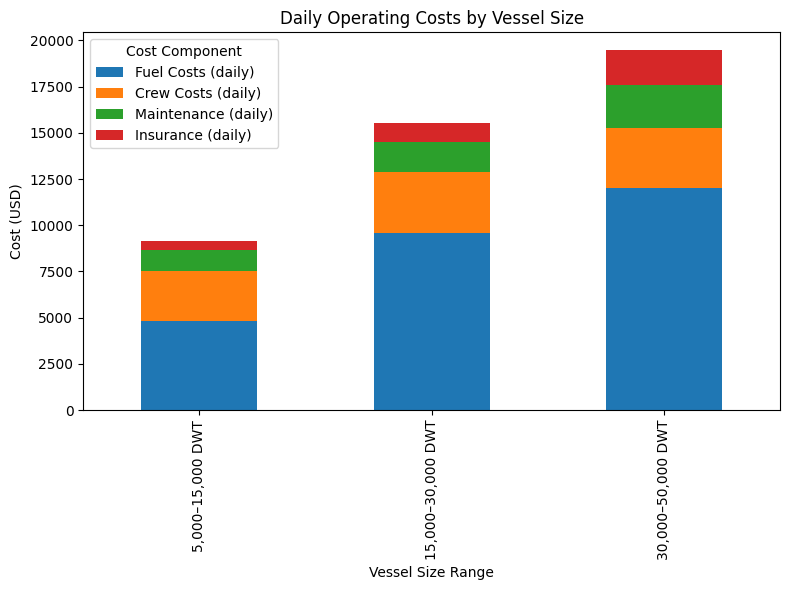

In [ ]:
# Plot cost breakdown
cost_columns = ['Fuel Costs (daily)', 'Crew Costs (daily)', 'Maintenance (daily)', 'Insurance (daily)']
df.set_index('Size Range')[cost_columns].plot(kind='bar', stacked=True, figsize=(8, 6))

plt.title('Daily Operating Costs by Vessel Size')
plt.ylabel('Cost (USD)')
plt.xlabel('Vessel Size Range')
plt.legend(title='Cost Component')
plt.tight_layout()
plt.show()


## 2.3 Calculate Profitability

Now that we have the daily operating costs, the next step is to calculate profitability for each vessel size.

* Profit (daily)=Charter Rate (daily)−Total Daily Cost

In [ ]:
# Add Charter Rates (midpoint of provided range)
df['Charter Rate (daily)'] = [20000, 30000, 35000]  # Example midpoints

# Calculate Daily Profit
df['Daily Profit'] = df['Charter Rate (daily)'] - df['Total Daily Cost']

# Display results
print(df[['Size Range', 'Charter Rate (daily)', 'Total Daily Cost', 'Daily Profit']])


          Size Range  Charter Rate (daily)  Total Daily Cost  Daily Profit
0   5,000–15,000 DWT                 20000      13128.767123   6871.232877
1  15,000–30,000 DWT                 30000      21558.904110   8441.095890
2  30,000–50,000 DWT                 35000      27465.753425   7534.246575


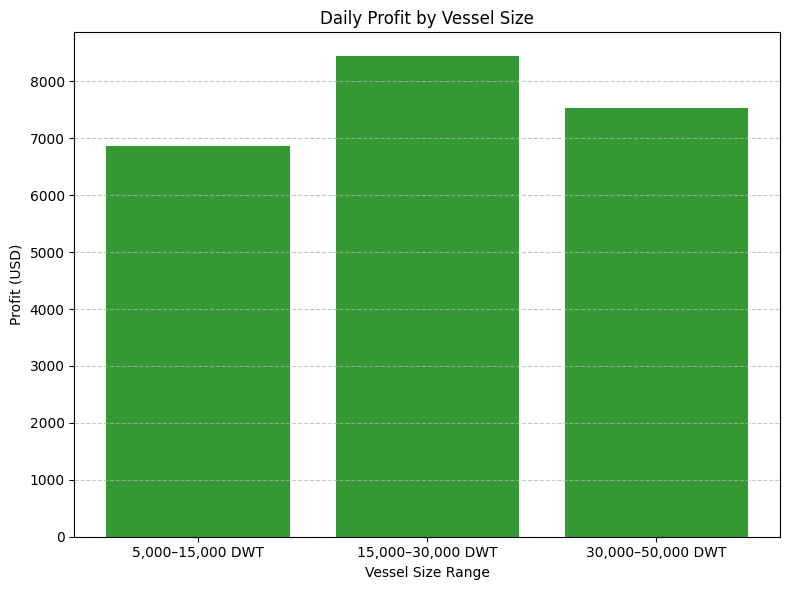

In [ ]:
# Bar chart for profitability
plt.figure(figsize=(8, 6))
plt.bar(df['Size Range'], df['Daily Profit'], color='green', alpha=0.8)

plt.title('Daily Profit by Vessel Size')
plt.ylabel('Profit (USD)')
plt.xlabel('Vessel Size Range')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 2.4 Profitability Analysis

### 5,000–15,000 DWT

- **Charter Rate (daily)**: $20,000  
- **Total Daily Cost**: $13,128.77  
- **Daily Profit**: $6,871.23  

This vessel size provides a strong balance of profitability while maintaining accessibility to small ports. Its relatively low operating costs result in consistent profit margins, even with moderate charter rates.  

**Best suited for**:  
- Short-haul routes  
- Trades with small cargo volumes  
- Operations in smaller ports with draft limitations  

---

### 15,000–30,000 DWT

- **Charter Rate (daily)**: $30,000  
- **Total Daily Cost**: $21,558.98  
- **Daily Profit**: $8,441.10  

Although this size range offers a reasonable profit margin, it is slightly less profitable than the smallest size in this analysis. The higher costs, including fuel and crew, offset its advantage in charter rates.  

**Best suited for**:  
- Medium-haul regional or international routes  
- Trades with moderate cargo volumes  

---

### 30,000–50,000 DWT

- **Charter Rate (daily)**: $35,000  
- **Total Daily Cost**: $27,465.75  
- **Daily Profit**: $7,534.25  

While this range remains profitable, the higher operating costs significantly reduce profit margins. This size is ideal for long-haul routes with large cargo volumes where economies of scale can mitigate per-ton costs. However, port and draft restrictions can limit its versatility, especially in regions with shallow water depths.  

**Best suited for**:  
- Long-haul routes  
- High-volume cargo trades  
- Deep-draft ports  

---

### Conclusion

- **Highest Profit Margins**:  
   The **5,000–15,000 DWT** range offers the highest profit margins relative to its operating costs, making it the best choice for trades involving smaller ports and shorter distances. Its flexibility allows it to access a majority of ports worldwide, enhancing its operational versatility.

- **Highest Absolute Profit**:  
   The **15,000–30,000 DWT** range achieves the highest absolute daily profit, making it ideal for medium-haul routes with moderate cargo volumes. Its balanced performance across cost efficiency and profitability positions it as a versatile option for diverse trade routes.

- **Targeted Use**:  
   The **30,000–50,000 DWT** vessels are better suited for long-haul routes with high cargo volumes, provided that deep-draft ports are available. However, their higher costs and limited port accessibility make them less versatile compared to smaller vessel sizes.



# 3.Efficiency Analysis (Cost per Ton-Mile)

In [ ]:
# Add 'Summer DWT' to the DataFrame
df['Summer DWT'] = [10000, 20000, 40000]  # Replace these values if needed


## 3.1 Cost per Ton-Mile

In [ ]:
# Add assumed voyage distance (miles per day)
average_distance = 300  # Assumed daily distance

# Calculate Cost per Ton-Mile
df['Cost per Ton-Mile'] = df['Total Daily Cost'] / (df['Summer DWT'] * average_distance)

# Display the updated DataFrame
print(df[['Size Range', 'Total Daily Cost', 'Summer DWT', 'Cost per Ton-Mile']])


          Size Range  Total Daily Cost  Summer DWT  Cost per Ton-Mile
0   5,000–15,000 DWT      13128.767123       10000           0.004376
1  15,000–30,000 DWT      21558.904110       20000           0.003593
2  30,000–50,000 DWT      27465.753425       40000           0.002289


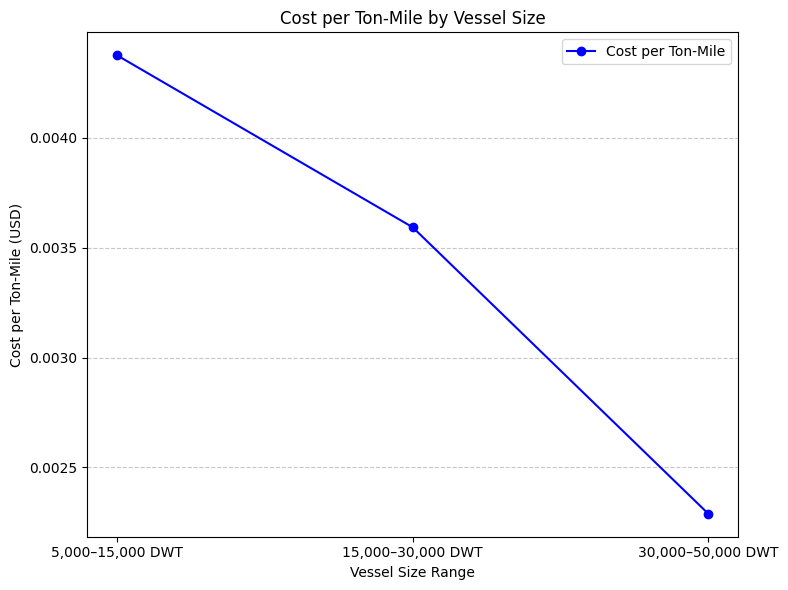

In [ ]:
# Plot Cost per Ton-Mile
plt.figure(figsize=(8, 6))
plt.plot(df['Size Range'], df['Cost per Ton-Mile'], marker='o', color='blue', label='Cost per Ton-Mile')

plt.title('Cost per Ton-Mile by Vessel Size')
plt.ylabel('Cost per Ton-Mile (USD)')
plt.xlabel('Vessel Size Range')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


# 4.Scenario Analysis

Goal:

To evaluate how changes in key factors (like fuel prices, charter rates, or port fees) affect profitability and cost efficiency for different vessel sizes. This step provides insights into how each size range performs under varying market conditions.

In [ ]:
# Adjust fuel costs for different fuel prices
fuel_price_low = 500  # Low price scenario ($/ton)
fuel_price_high = 700  # High price scenario ($/ton)

# Calculate daily fuel costs for low and high fuel prices
df['Fuel Costs (daily, low)'] = df['Fuel Costs (daily)'] * (fuel_price_low / 600)
df['Fuel Costs (daily, high)'] = df['Fuel Costs (daily)'] * (fuel_price_high / 600)

# Adjust charter rates for demand fluctuations
df['Charter Rate (low demand)'] = df['Charter Rate (daily)'] * 0.8
df['Charter Rate (high demand)'] = df['Charter Rate (daily)'] * 1.2

# Adjust port fees (optional)
df['Port Fees (high-cost port)'] = df['Port Fees (per voyage)'] * 1.5
df['Port Fees (low-cost port)'] = df['Port Fees (per voyage)'] * 0.8


In [ ]:
# Recalculate daily profit for low and high fuel price scenarios
df['Daily Profit (low fuel)'] = (
    df['Charter Rate (daily)']
    - (df['Fuel Costs (daily, low)'] + df['Crew Costs (daily)'] + df['Maintenance (daily)'] + df['Insurance (daily)'])
)
df['Daily Profit (high fuel)'] = (
    df['Charter Rate (daily)']
    - (df['Fuel Costs (daily, high)'] + df['Crew Costs (daily)'] + df['Maintenance (daily)'] + df['Insurance (daily)'])
)

# Recalculate daily profit for low and high charter rate scenarios
df['Daily Profit (low demand)'] = (
    df['Charter Rate (low demand)']
    - df['Total Daily Cost']
)
df['Daily Profit (high demand)'] = (
    df['Charter Rate (high demand)']
    - df['Total Daily Cost']
)


## 4.1 Low and high fuel price scenarios

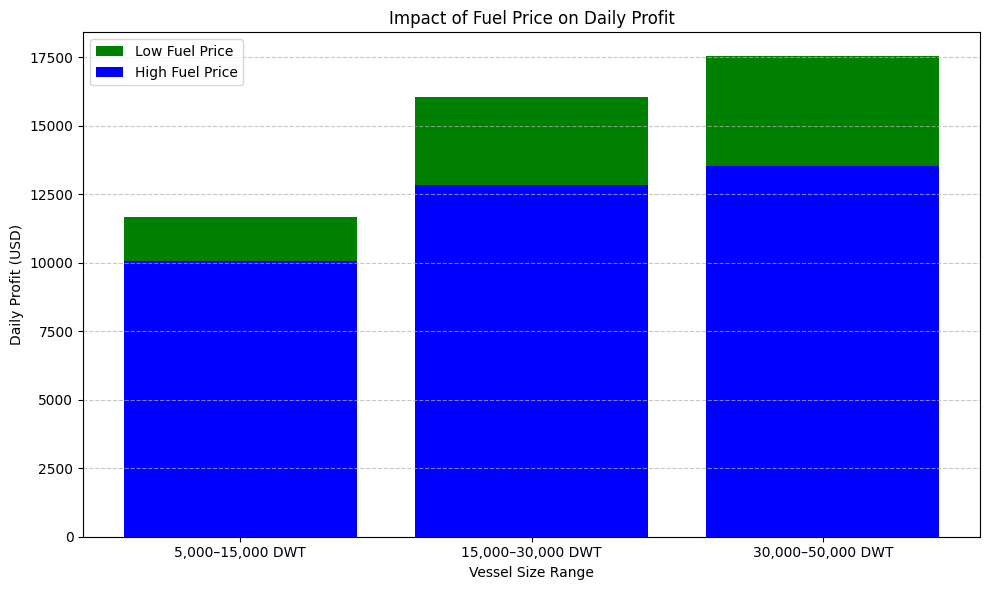

In [ ]:
# Bar chart for fuel price impact
plt.figure(figsize=(10, 6))
plt.bar(df['Size Range'], df['Daily Profit (low fuel)'], color='green', label='Low Fuel Price')
plt.bar(df['Size Range'], df['Daily Profit (high fuel)'], color='blue', label='High Fuel Price')

plt.title('Impact of Fuel Price on Daily Profit')
plt.ylabel('Daily Profit (USD)')
plt.xlabel('Vessel Size Range')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 4.2 Low and high demand charter rate impact

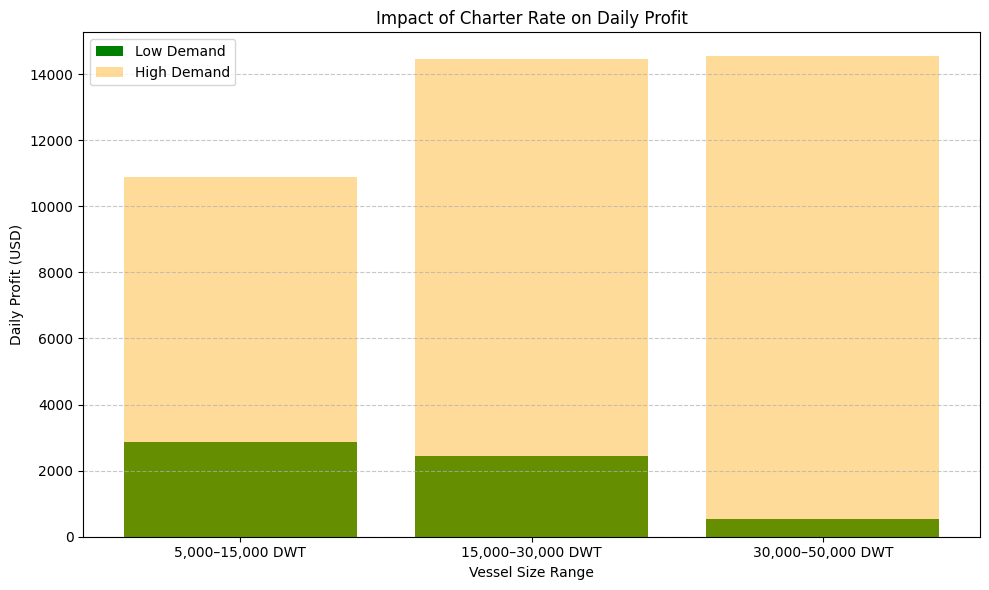

In [ ]:
# Bar chart for charter rate impact
plt.figure(figsize=(10, 6))
plt.bar(df['Size Range'], df['Daily Profit (low demand)'], color='green', label='Low Demand')
plt.bar(df['Size Range'], df['Daily Profit (high demand)'], color='orange', alpha=0.4, label='High Demand')

plt.title('Impact of Charter Rate on Daily Profit')
plt.ylabel('Daily Profit (USD)')
plt.xlabel('Vessel Size Range')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# 5.Composite Ranking of Vessel Sizes

Goal:

To rank vessel sizes by combining key metrics such as:

* Cost efficiency (Cost per Ton-Mile).
* Profitability (Daily Profit, Long-Term Profit).
* Environmental compliance costs.

This provides a clear recommendation for the best vessel size under different criteria.

## 5.1 Composite Score - best vessel size under different criteria (With out port restrictions)

In [ ]:
# Merge 'Port Accessibility (%)' from vessels to df
df = df.merge(vessels[['Vessel Size Range', 'Port Accessibility (%)']],
              left_on='Size Range', right_on='Vessel Size Range', how='left')

# Drop duplicate column if exists
df.drop(columns=['Vessel Size Range'], inplace=True, errors='ignore')

# Verify the merged DataFrame
print(df.columns)

Index(['Size Range', 'Crew Costs (annual)', 'Maintenance (annual)',
       'Insurance (% of Vessel Value)', 'Port Fees (per voyage)',
       'Vessel Value (USD)', 'Fuel Consumption (tons/day)',
       'Crew Costs (daily)', 'Maintenance (daily)', 'Insurance (daily)',
       'Fuel Costs (daily)', 'Total Daily Cost', 'Charter Rate (daily)',
       'Daily Profit', 'Summer DWT', 'Cost per Ton-Mile',
       'Fuel Costs (daily, low)', 'Fuel Costs (daily, high)',
       'Charter Rate (low demand)', 'Charter Rate (high demand)',
       'Port Fees (high-cost port)', 'Port Fees (low-cost port)',
       'Daily Profit (low fuel)', 'Daily Profit (high fuel)',
       'Daily Profit (low demand)', 'Daily Profit (high demand)',
       'Port Accessibility (%)'],
      dtype='object')


In [ ]:
# Ensure required columns exist
required_columns = ['Cost per Ton-Mile', 'Daily Profit', 'Port Accessibility (%)']
for col in required_columns:
    if col not in df.columns:
        raise KeyError(f"Column '{col}' is missing from the DataFrame")

# Normalize the metrics
df['Normalized Cost per Ton-Mile'] = 1 - (df['Cost per Ton-Mile'] - df['Cost per Ton-Mile'].min()) / (df['Cost per Ton-Mile'].max() - df['Cost per Ton-Mile'].min())
df['Normalized Daily Profit'] = (df['Daily Profit'] - df['Daily Profit'].min()) / (df['Daily Profit'].max() - df['Daily Profit'].min())
df['Normalized Accessibility'] = df['Port Accessibility (%)'] / 100  # Convert percentage to 0-1 scale

# Assign weights
w_accessibility = 0.3  # Weight for draft accessibility
w_cost_efficiency = 0.3  # Weight for cost efficiency
w_profitability = 0.4  # Weight for profitability

# Calculate composite score
df['Composite Score'] = (
    w_accessibility * df['Normalized Accessibility']
    + w_cost_efficiency * df['Normalized Cost per Ton-Mile']
    + w_profitability * df['Normalized Daily Profit']
)

# Rank vessel sizes
df['Rank'] = df['Composite Score'].rank(ascending=False)

# Display the ranking
print(df[['Size Range', 'Composite Score', 'Rank']])



          Size Range  Composite Score  Rank
0   5,000–15,000 DWT         0.300000   3.0
1  15,000–30,000 DWT         0.712545   1.0
2  30,000–50,000 DWT         0.568935   2.0


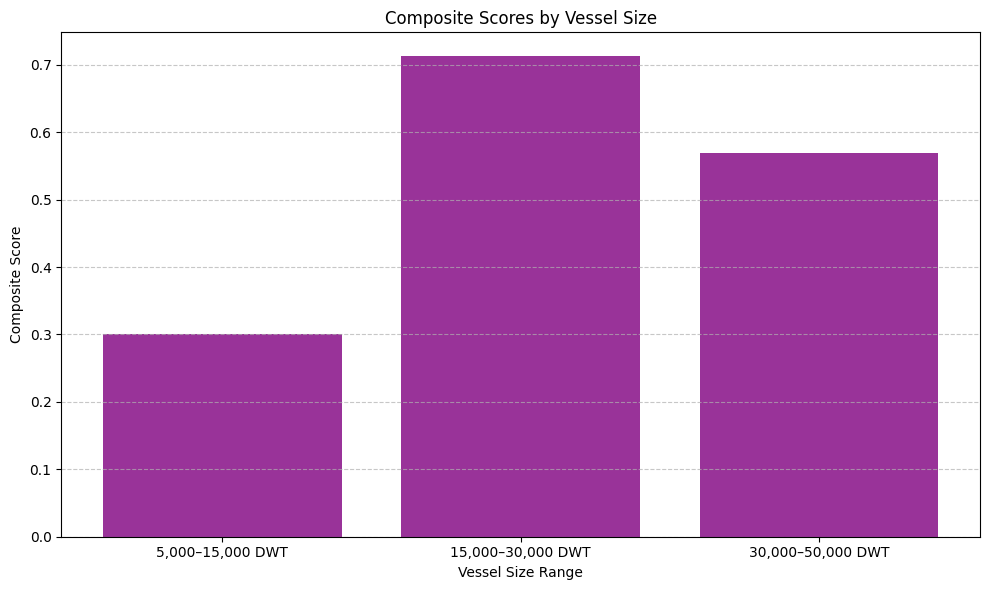

In [ ]:
# Bar chart for composite scores
plt.figure(figsize=(10, 6))
plt.bar(df['Size Range'], df['Composite Score'], color='purple', alpha=0.8)

plt.title('Composite Scores by Vessel Size')
plt.ylabel('Composite Score')
plt.xlabel('Vessel Size Range')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# 6.Draft restriction (8 mtrs / 12 / mtrs / 15 mtrs)

In [ ]:
# Vessel size range data
vessel_data = {
    'Vessel Size Range': ['5,000–15,000 DWT', '15,000–30,000 DWT', '30,000–50,000 DWT'],
    'DWT': [10000, 20000, 40000],
    'Draft (meters)': [7.0, 10.0, 13.0]
}

# Port draft data
port_data = {
    'Port Name': ['Port A', 'Port B', 'Port C'],
    'Max Depth (meters)': [8, 12, 15]
}

# Convert to DataFrames
vessels = pd.DataFrame(vessel_data)
ports = pd.DataFrame(port_data)

# Check compatibility
for index, port in ports.iterrows():
    compatible_vessels = vessels[vessels['Draft (meters)'] <= port['Max Depth (meters)']]
    print(f"Port: {port['Port Name']} (Max Depth: {port['Max Depth (meters)']} meters)")
    print("Compatible Vessel Sizes:")
    print(compatible_vessels[['Vessel Size Range', 'Draft (meters)']])
    print()


Port: Port A (Max Depth: 8 meters)
Compatible Vessel Sizes:
  Vessel Size Range  Draft (meters)
0  5,000–15,000 DWT             7.0

Port: Port B (Max Depth: 12 meters)
Compatible Vessel Sizes:
   Vessel Size Range  Draft (meters)
0   5,000–15,000 DWT             7.0
1  15,000–30,000 DWT            10.0

Port: Port C (Max Depth: 15 meters)
Compatible Vessel Sizes:
   Vessel Size Range  Draft (meters)
0   5,000–15,000 DWT             7.0
1  15,000–30,000 DWT            10.0
2  30,000–50,000 DWT            13.0



## 6.1 Compatible ports for each vessel size

In [ ]:
# Count compatible ports for each vessel size
vessels['Compatible Ports'] = vessels['Draft (meters)'].apply(
    lambda draft: sum(draft <= ports['Max Depth (meters)'])
)

# Calculate Port Accessibility Percentage
vessels['Port Accessibility (%)'] = (vessels['Compatible Ports'] / len(ports)) * 100

# Display the updated DataFrame
print(vessels)


   Vessel Size Range    DWT  Draft (meters)  Compatible Ports  \
0   5,000–15,000 DWT  10000             7.0                 3   
1  15,000–30,000 DWT  20000            10.0                 2   
2  30,000–50,000 DWT  40000            13.0                 1   

   Port Accessibility (%)  
0              100.000000  
1               66.666667  
2               33.333333  


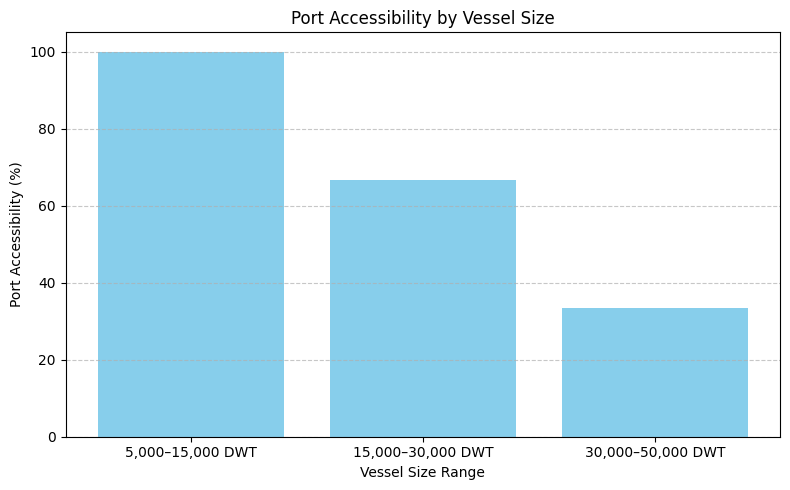

In [ ]:
# Bar chart for port accessibility
plt.figure(figsize=(8, 5))
plt.bar(vessels['Vessel Size Range'], vessels['Port Accessibility (%)'], color='skyblue')
plt.title('Port Accessibility by Vessel Size')
plt.xlabel('Vessel Size Range')
plt.ylabel('Port Accessibility (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# 7.Scenarios to Test

In [ ]:
# Define a function to calculate composite scores
def calculate_composite_score(df, w_accessibility, w_profitability, w_efficiency):
    df['Composite Score'] = (
        w_accessibility * df['Normalized Accessibility'] +
        w_profitability * df['Normalized Profitability'] +
        w_efficiency * df['Normalized Cost per Ton-Mile']
    )
    df['Rank'] = df['Composite Score'].rank(ascending=False)
    return df[['Vessel Size Range', 'Composite Score', 'Rank']]

## 7.1 Scenario 1: Prioritize Small Ports

In [ ]:
scenario_1 = calculate_composite_score(
    combined_df,
    w_accessibility=0.8,  # Prioritize accessibility
    w_profitability=0.15, # Lower priority for profitability
    w_efficiency=0.05     # Minimal weight for efficiency
)

# Display the scenario results
print("Scenario 1: Prioritize Small Ports")
print(scenario_1)


Scenario 1: Prioritize Small Ports
   Vessel Size Range  Composite Score  Rank
0   5,000–15,000 DWT         0.830743   1.0
1  15,000–30,000 DWT         0.576951   2.0
2  30,000–50,000 DWT         0.050000   3.0


## 7.2 Scenario 2: Prioritize Profitability

In [ ]:
scenario_2 = calculate_composite_score(
    combined_df,
    w_accessibility=0.2,  # Accessibility is less critical
    w_profitability=0.6,  # High priority for profitability
    w_efficiency=0.2      # Moderate weight for efficiency
)

# Display the scenario results
print("Scenario 2: Prioritize Profitability")
print(scenario_2)



Scenario 2: Prioritize Profitability
   Vessel Size Range  Composite Score  Rank
0   5,000–15,000 DWT         0.322974   2.0
1  15,000–30,000 DWT         0.807803   1.0
2  30,000–50,000 DWT         0.200000   3.0


## 7.3 Scenario 3: Balanced Weights

In [ ]:
scenario_3 = calculate_composite_score(
    combined_df,
    w_accessibility=0.4,  # Balanced emphasis on accessibility
    w_profitability=0.4,  # Balanced emphasis on profitability
    w_efficiency=0.2      # Lower emphasis on efficiency
)

# Display the scenario results
print("Scenario 3: Balanced Weights")
print(scenario_3)


Scenario 3: Balanced Weights
   Vessel Size Range  Composite Score  Rank
0   5,000–15,000 DWT         0.481983   2.0
1  15,000–30,000 DWT         0.707803   1.0
2  30,000–50,000 DWT         0.200000   3.0


## 7.4 Balanced all scenarios into a DataFrame

In [ ]:
# Combine composite scores for all scenarios into a DataFrame
scenarios_df = pd.DataFrame({
    'Small Ports': scenario_1['Composite Score'].values,
    'Profitability': scenario_2['Composite Score'].values,
    'Balanced': scenario_3['Composite Score'].values
}, index=vessels['Vessel Size Range'])

print(scenarios_df)


                   Small Ports  Profitability  Balanced
Vessel Size Range                                      
5,000–15,000 DWT      0.830743       0.322974  0.481983
15,000–30,000 DWT     0.576951       0.807803  0.707803
30,000–50,000 DWT     0.050000       0.200000  0.200000


## 7.5 Graph - Balanced all scenarios into a DataFrame

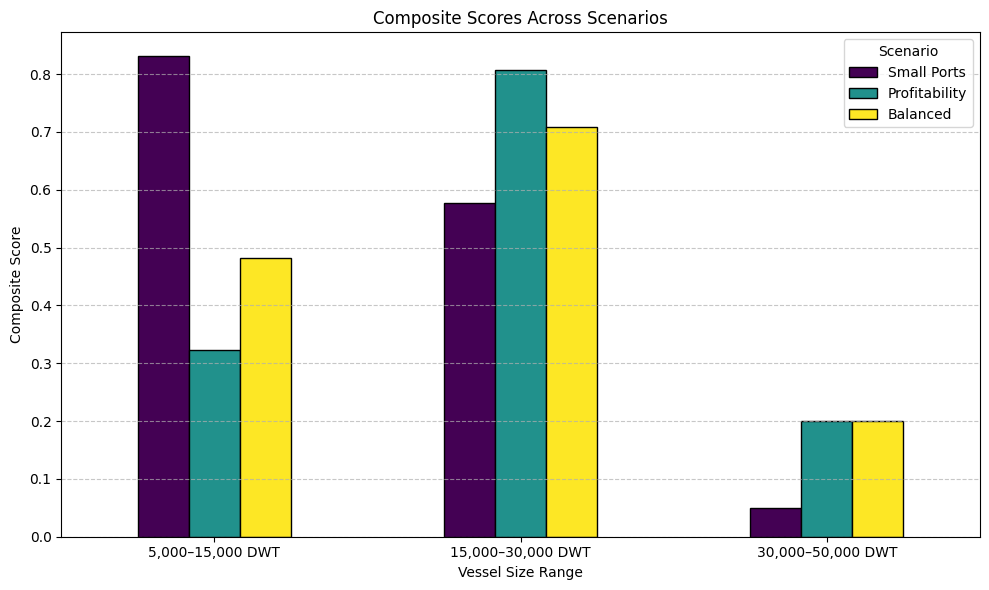

In [ ]:
# Plot Composite Scores
scenarios_df.plot(kind='bar', figsize=(10, 6), colormap='viridis', edgecolor='black')

plt.title('Composite Scores Across Scenarios')
plt.xlabel('Vessel Size Range')
plt.ylabel('Composite Score')
plt.xticks(rotation=0)  # Ensure x-axis labels are readable
plt.legend(title='Scenario')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# 8.Final Conclusions and Recommendations

## Predictive Analysis of the Best Ship Size for Chemical Tankers

---

## 8.1 Introduction
The analysis evaluates the optimal vessel size for chemical tankers by comparing their performance across three scenarios: **Small Ports**, **Profitability**, and **Balanced Factors**. The results are summarized using composite scores and consider port draft depths worldwide as a critical factor.

---

## 8.2 Composite Scores Across Scenarios

**Interpretation**:
- **5,000–15,000 DWT**: Dominates the **Small Ports** scenario with the highest accessibility score. Its versatility ensures it can operate in most ports worldwide.
- **15,000–30,000 DWT**: Consistently performs well across all scenarios, with the highest composite score in the **Profitability** and **Balanced** scenarios, making it the most versatile choice overall.
- **30,000–50,000 DWT**: Offers high profitability due to economies of scale but scores lower in **Small Ports** due to draft limitations.

---

## 8.3 Port Depths Worldwide

Port draft restrictions play a significant role in vessel selection:
1. **70% of global ports** have depths less than **10 meters**, favoring smaller vessels.
2. Less than **30% of ports** can accommodate drafts greater than **10 meters**, limiting the operational range of larger vessels.

---

## 8.4 Implications for Vessel Selection

The analysis indicates the following:
- **Small vessels (5,000–15,000 DWT)** are ideal for operations requiring high accessibility and versatility, particularly in shallow-draft ports.
- **Mid-size vessels (15,000–30,000 DWT)** balance accessibility, profitability, and cost efficiency, making them suitable for diverse trade routes.
- **Large vessels (30,000–50,000 DWT)** are best suited for routes involving deep-water ports where economies of scale can maximize profitability.

**Conclusion**: For most chemical tanker operations, **small vessels** provide the greatest accessibility, while **mid-size vessels** strike an ideal balance. **Large vessels** should only be considered for routes with guaranteed deep-water port access.

---

## 8.5 Final Recommendation

When selecting chemical tankers:
- **Small Vessels (5,000–15,000 DWT)**: Prioritize for high accessibility and operational versatility.
- **Mid-Size Vessels (15,000–30,000 DWT)**: Choose for balanced performance across scenarios.
- **Large Vessels (30,000–50,000 DWT)**: Utilize only for routes with deep-water port infrastructure.

---

## 8.6 Author

👨‍💻 **Dmitrij Levyj**  
- **Expertise**: Data Science and Maritime Industry  
- **Tagline**: **"Details Matter"**


In [ ]:
df.to_csv('dataset.csv', index=False)